## Parte 4: Geoestadística y Análisis Avanzado 

In [13]:
#!pip install geopandas numpy pandas scikit-gstat pykrige rasterio shapely matplotlib scipy seaborn python-dotenv sqlalchemy

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
import json

# Variogramas
from skgstat import Variogram, DirectionalVariogram

# Kriging
from pykrige.ok import OrdinaryKriging

# IDW
from scipy.spatial import cKDTree

# Métricas
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ráster
import rasterio
from rasterio.transform import from_origin
from rasterio.crs import CRS

# --- CONFIGURACIÓN DE RUTAS DE SALIDA ---
BASE_DIR = Path('..')
OUTPUTS_DIR = BASE_DIR / 'outputs'
FIG_DIR = OUTPUTS_DIR / 'figures'
MODELS_DIR = OUTPUTS_DIR / 'models'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

# Crear carpetas si no existen
for d in [FIG_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"📂 Directorio verificado: {d}")

# Configuración visual
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 12)

# Cargar variables de entorno y conexión BD
load_dotenv()
DB_USER = os.getenv('POSTGRES_USER', 'geouser')
DB_PASS = os.getenv('POSTGRES_PASSWORD', 'geopass')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'geodatabase')

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("✅ Conexión a PostGIS establecida")


📂 Directorio verificado: ../outputs/figures
📂 Directorio verificado: ../outputs/models
📂 Directorio verificado: ../outputs/reports
✅ Conexión a PostGIS establecida


In [14]:
import rasterio
from rasterio.mask import mask

print("⏳ Cargando y unificando tablas procesadas...")

# 1. Carga de tablas
gdf = gpd.read_postgis("SELECT * FROM processed_data.manzanas_atributos", engine, geom_col='geometry')
df_net = pd.read_sql("SELECT * FROM processed_data.metrics_network", engine)
df_env = pd.read_sql("SELECT * FROM processed_data.metrics_manzanas", engine)

# NUEVO: Cargamos el Uso de Suelo para sacar la categoría
# (Hacemos un truco: agrupamos por manzana y nos quedamos con el uso de suelo principal si hay solapamiento)
df_usos = pd.read_sql("SELECT manzent, nom FROM processed_data.manzanas_uso_suelo", engine)
# Si una manzana toca dos usos, nos quedamos con el primero para simplificar el análisis maestro
df_usos = df_usos.drop_duplicates(subset='manzent')

# Conversión de llaves
gdf['manzent'] = gdf['manzent'].astype(str)
df_net['manzent'] = df_net['manzent'].astype(str)
df_env['manzent'] = df_env['manzent'].astype(str)
df_usos['manzent'] = df_usos['manzent'].astype(str)

# --- MERGES (Unión) ---
gdf_master = gdf.merge(df_net, on='manzent', how='left')
# Unir Entorno
cols_env = [c for c in df_env.columns if c not in gdf_master.columns and c != 'manzent']
gdf_master = gdf_master.merge(df_env[['manzent'] + cols_env], on='manzent', how='left')
# Unir Uso de Suelo (Columna 'nom')
gdf_master = gdf_master.merge(df_usos[['manzent', 'nom']], on='manzent', how='left')

# Rellenar nulos numéricos
fill_cols = ['degree_mean', 'betweenness_mean', 'road_length_m', 'road_density_km2', 'num_edificios', 'num_amenidades']
for c in fill_cols:
    if c in gdf_master.columns:
        gdf_master[c] = gdf_master[c].fillna(0)
        
# Rellenar nulos categóricos
gdf_master['nom'] = gdf_master['nom'].fillna('Sin Clasificar')

gdf_master['pop_density'] = gdf_master['total_personas'] / (gdf_master.geometry.area / 10000)

# --- ESTADÍSTICAS ZONALES RASTER ---
def calculate_zonal_stats(gdf, raster_path):
    if not os.path.exists(raster_path): return np.nan
    means = []
    with rasterio.open(raster_path) as src:
        gdf_proj = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        for geom in gdf_proj.geometry:
            try:
                out_image, _ = mask(src, [geom], crop=True, nodata=np.nan)
                data = out_image[0][(out_image[0] != src.nodata) & (~np.isnan(out_image[0]))]
                means.append(np.mean(data) if data.size > 0 else 0)
            except: means.append(0)
    return means

gdf_master['ndvi_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/sentinel2_ndvi.tif')
gdf_master['slope_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/slope.tif')

print(f"✅ Dataset Maestro Actualizado: {len(gdf_master)} manzanas.")
print("   Incluye columna 'nom' para análisis de Uso de Suelo.")

⏳ Cargando y unificando tablas procesadas...
✅ Dataset Maestro Actualizado: 792 manzanas.
   Incluye columna 'nom' para análisis de Uso de Suelo.


In [15]:
# Mostrar nombres de columnas
print(gdf_master.columns.tolist())

# Mostrar las primeras 10 filas
print(gdf_master.head(10))

['fid', 'cut', 'region_x', 'provincia_x', 'comuna_x', 'nombre_distrito', 'codigo_distrito', 'manzent', 'zona_censal', 'manzana', 'total_personas', 'total_hombres', 'total_mujeres', 'personas_0_a_5_años', 'personas_6_a_14_años', 'personas_15_a_64_años', 'personas_mas_65_años', 'personas_emigrantes', 'pueblos_indigena_originario', 'total_viv_particulares', 'total_viv_colectivas', 'viv_ocupa_morador_presente', 'total_viviendas', 'cantidad_hogares', 'viv_tipo_casa', 'viv_tipo_depto', 'viv_tipo_trad_indigena', 'viv_tipo_pieza', 'viv_tipo_mediagua', 'viv_tipo_movil', 'viv_tipo_otro_tipo', 'viv_pared_hormigon_armado', 'viv_pared_albañileria', 'viv_pared_tabique_forrado', 'viv_pared_tabique_sin_forro', 'viv_pared_adobe_barro', 'viv_pared_material_precario', 'viv_techo_tejas', 'viv_techo_losa_hormigon', 'viv_techo_planchas', 'viv_techo_fonolita', 'viv_techo_paja', 'viv_techo_mat_precarios', 'viv_techo_sin_cubierta_solida', 'viv_piso_parquet_flotante', 'viv_piso_radier', 'viv_piso_baldosa', 'viv

### Funciones auxiliares


Parámetros del variograma
  variable: pop_density
  model: spherical
  nugget: 1748.4763148018385
  sill: 12218.788865436933
  range: 0.0
  bins_count: 12


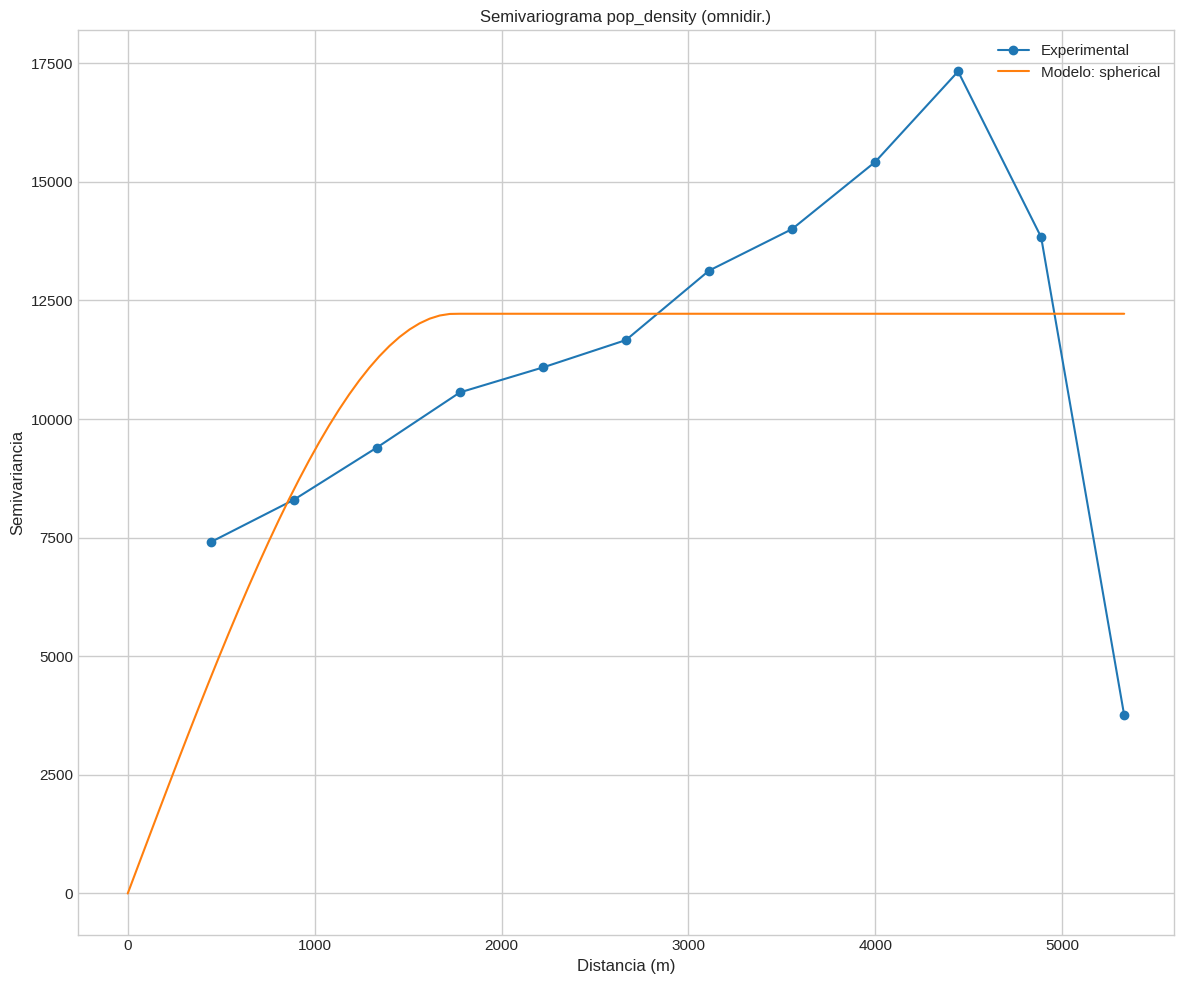


Variograma experimental (primeras filas)
   distance_bin_m         gamma
0      444.288328   7406.120178
1      888.576655   8297.810743
2     1332.864983   9398.358153
3     1777.153310  10560.990562
4     2221.441638  11087.437620

Resumen estadístico:
       distance_bin_m         gamma
count       12.000000     12.000000
mean      2887.874129  11323.301992
std       1601.904346   3762.433552
min        444.288328   3758.052331
25%       1666.081228   9123.221300
50%       2887.874129  11375.878022
75%       4109.667030  13875.583135
max       5331.459931  17326.175406

Kriging pop_density
Predicción:
  min=93.248, max=333.182, mean=163.604
Varianza:
  min=6894.093, max=8390.412, mean=7165.067


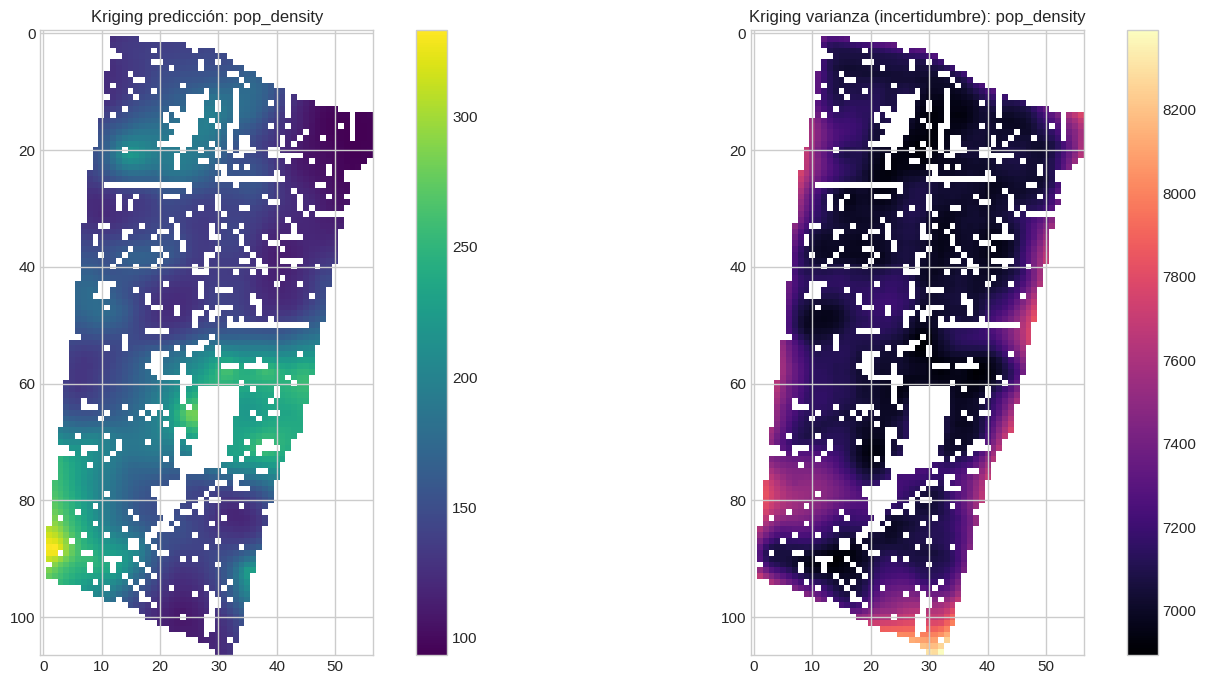


IDW pop_density
  min=1.304, max=838.807, mean=163.783


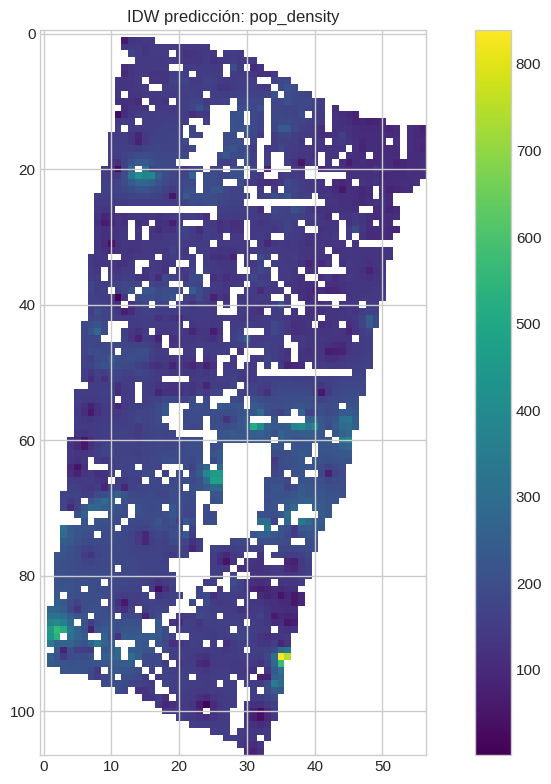


Validación cruzada
   fold   method        MAE        RMSE        R2     variable
0     1  Kriging  56.020707   79.658112  0.171760  pop_density
1     1      IDW  52.874291   73.880732  0.287543  pop_density
2     2  Kriging  59.491151   94.910927  0.228423  pop_density
3     2      IDW  57.852034   90.654036  0.296083  pop_density
4     3  Kriging  56.811299  109.489939  0.092902  pop_density
5     3      IDW  55.207542  105.275875  0.161383  pop_density
6     4  Kriging  47.281334   71.724709  0.347544  pop_density
7     4      IDW  46.394900   69.019923  0.395825  pop_density
8     5  Kriging  62.034761  106.059074  0.135768  pop_density
9     5      IDW  59.816621   99.975260  0.232074  pop_density

Resumen por método:
               MAE       RMSE        R2
method                                 
IDW      54.429077  87.761165  0.274582
Kriging  56.327851  92.368552  0.195279

Parámetros del variograma
  variable: ndvi_mean
  model: spherical
  nugget: 1260.6217099202079
  sill: 0

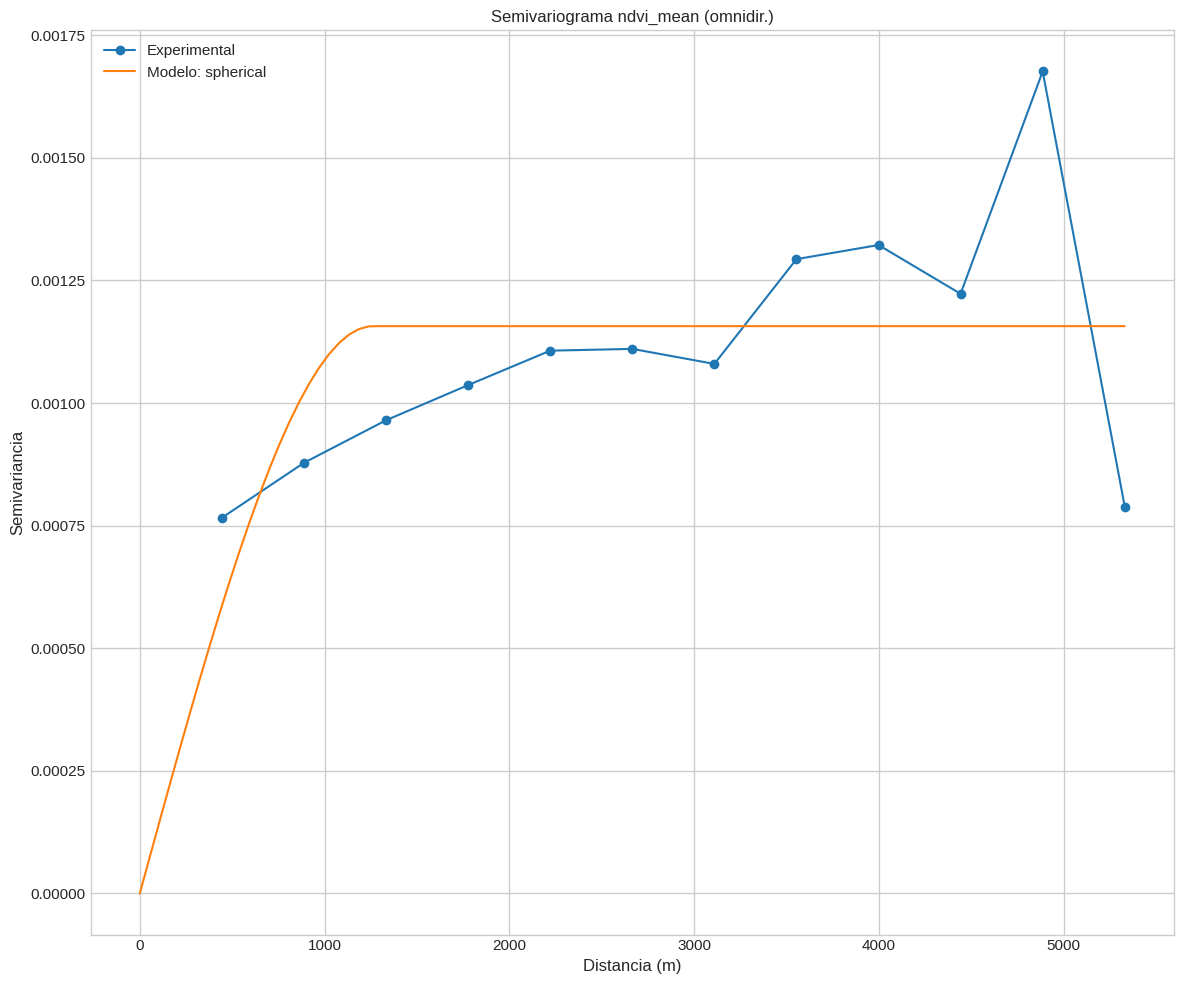


Variograma experimental (primeras filas)
   distance_bin_m     gamma
0      444.288328  0.000766
1      888.576655  0.000878
2     1332.864983  0.000965
3     1777.153310  0.001037
4     2221.441638  0.001107

Resumen estadístico:
       distance_bin_m      gamma
count       12.000000  12.000000
mean      2887.874129   0.001104
std       1601.904346   0.000255
min        444.288328   0.000766
25%       1666.081228   0.000943
50%       2887.874129   0.001093
75%       4109.667030   0.001240
max       5331.459931   0.001676

Kriging ndvi_mean
Predicción:
  min=0.053, max=0.134, mean=0.083
Varianza:
  min=0.001, max=0.001, mean=0.001


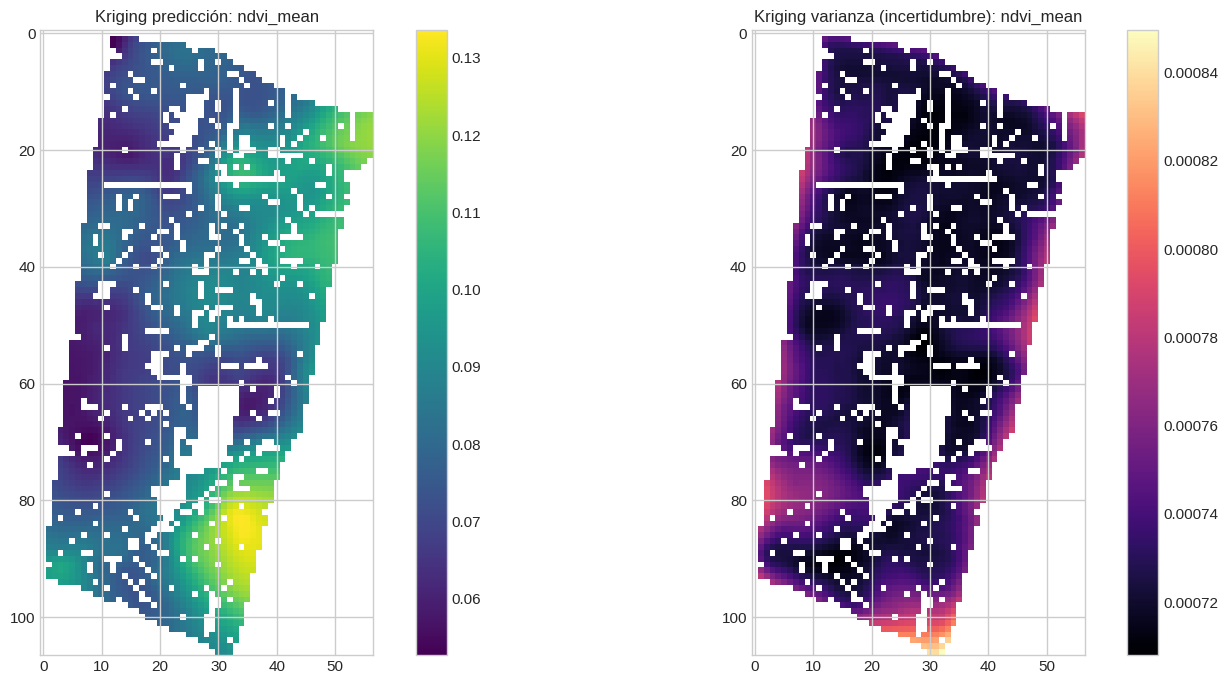


IDW ndvi_mean
  min=0.000, max=0.239, mean=0.083


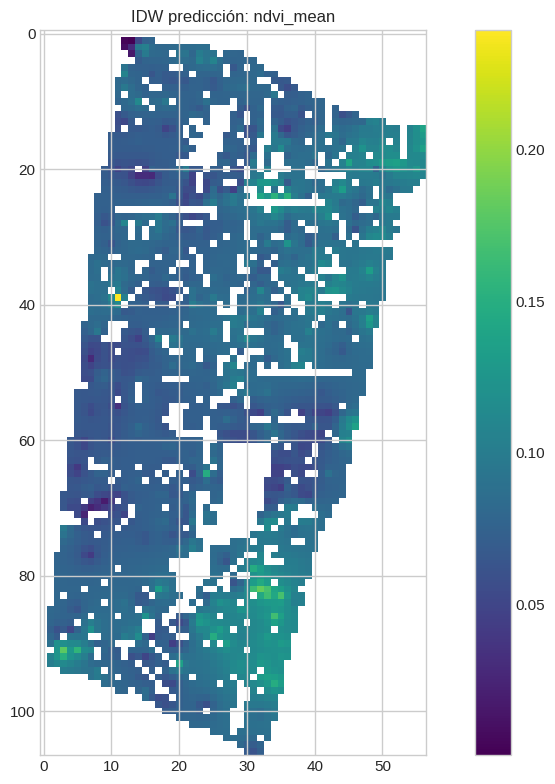


Validación cruzada
   fold   method       MAE      RMSE        R2   variable
0     1  Kriging  0.022518  0.030275  0.203998  ndvi_mean
1     1      IDW  0.020987  0.028472  0.295997  ndvi_mean
2     2  Kriging  0.020654  0.028275  0.279924  ndvi_mean
3     2      IDW  0.019187  0.026857  0.350352  ndvi_mean
4     3  Kriging  0.018721  0.024281  0.294470  ndvi_mean
5     3      IDW  0.016295  0.021877  0.427268  ndvi_mean
6     4  Kriging  0.019321  0.023789  0.383049  ndvi_mean
7     4      IDW  0.018166  0.022649  0.440752  ndvi_mean
8     5  Kriging  0.021083  0.028477  0.276286  ndvi_mean
9     5      IDW  0.019449  0.026582  0.369375  ndvi_mean

Resumen por método:
              MAE      RMSE        R2
method                               
IDW      0.018817  0.025287  0.376749
Kriging  0.020459  0.027019  0.287546

Parámetros del variograma
  variable: slope_mean
  model: spherical
  nugget: 5331.459931008187
  sill: 162.83087972015608
  range: 0.0
  bins_count: 12


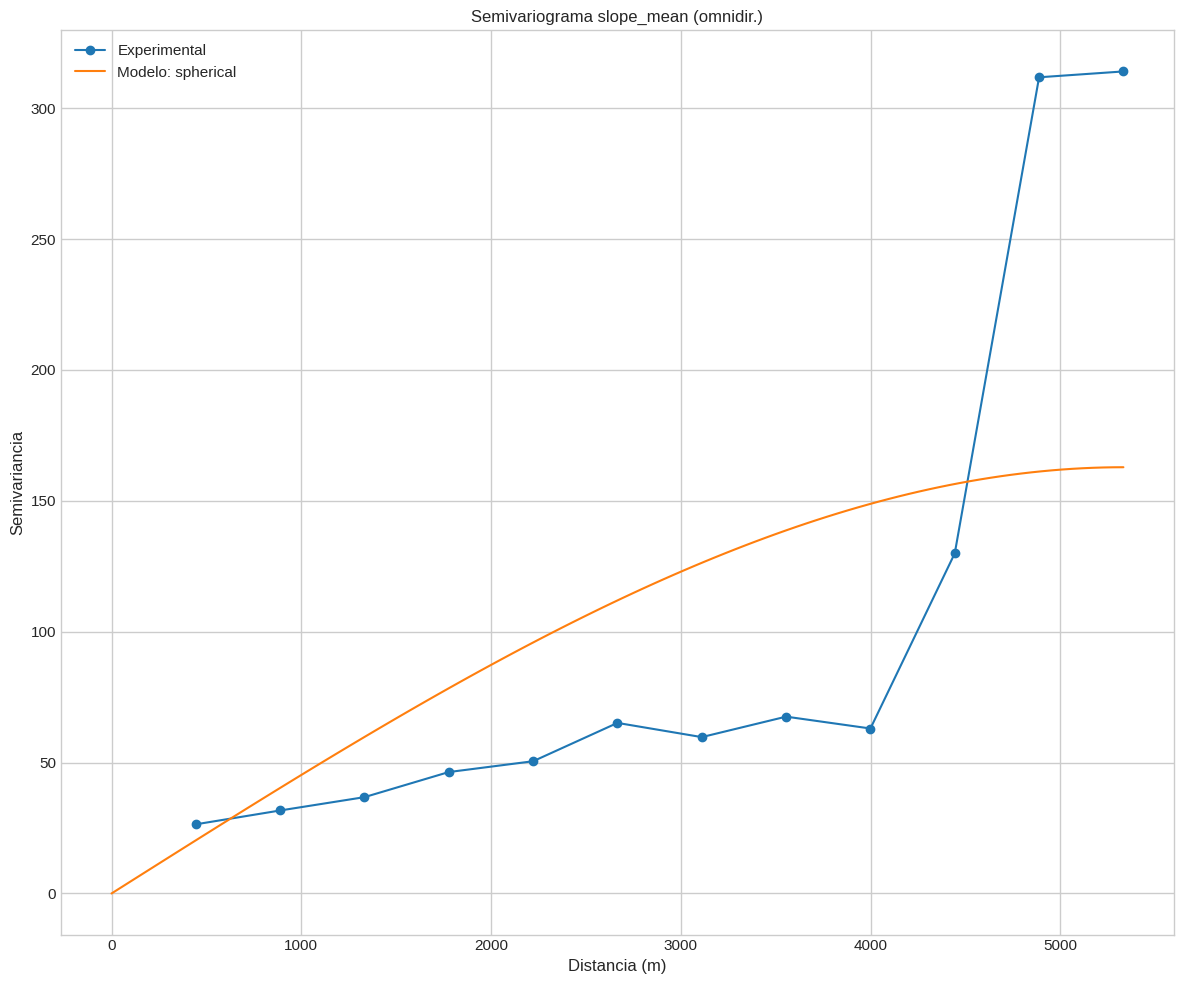


Variograma experimental (primeras filas)
   distance_bin_m      gamma
0      444.288328  26.421019
1      888.576655  31.708861
2     1332.864983  36.801721
3     1777.153310  46.387376
4     2221.441638  50.517187

Resumen estadístico:
       distance_bin_m       gamma
count       12.000000   12.000000
mean      2887.874129  100.252675
std       1601.904346  102.781372
min        444.288328   26.421019
25%       1666.081228   43.990963
50%       2887.874129   61.377045
75%       4109.667030   83.144818
max       5331.459931  314.022129

Kriging slope_mean
Predicción:
  min=0.465, max=44.049, mean=3.968
Varianza:
  min=7.139, max=15.453, mean=9.050


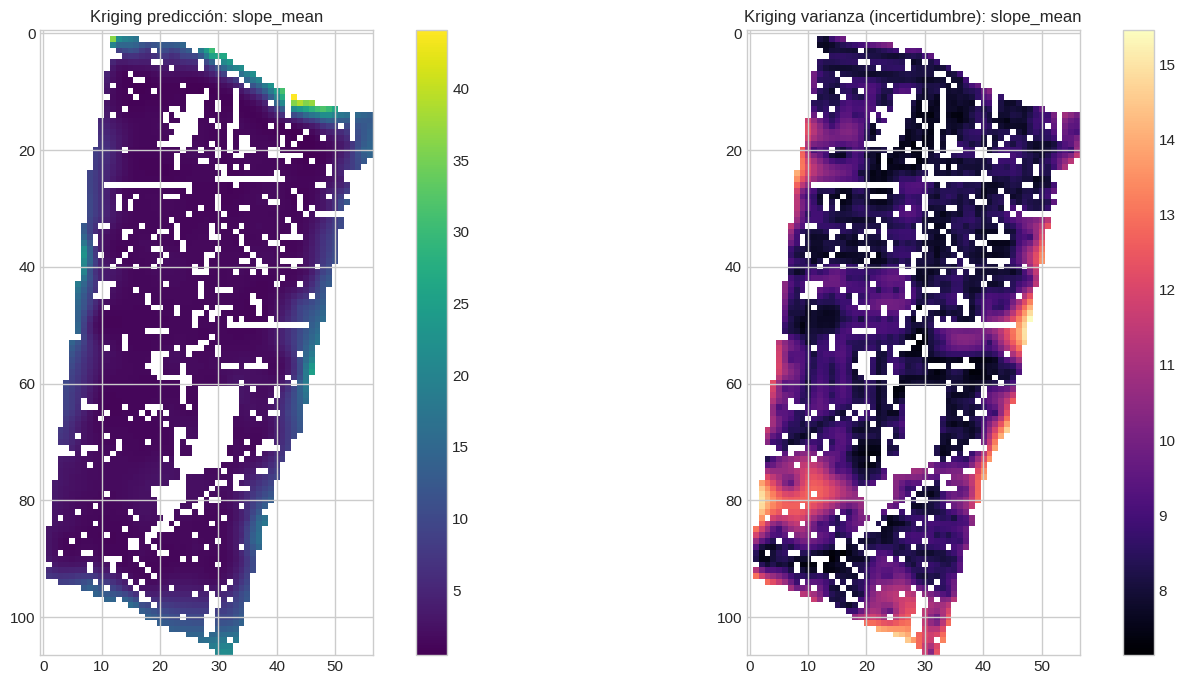


IDW slope_mean
  min=0.748, max=79.591, mean=3.152


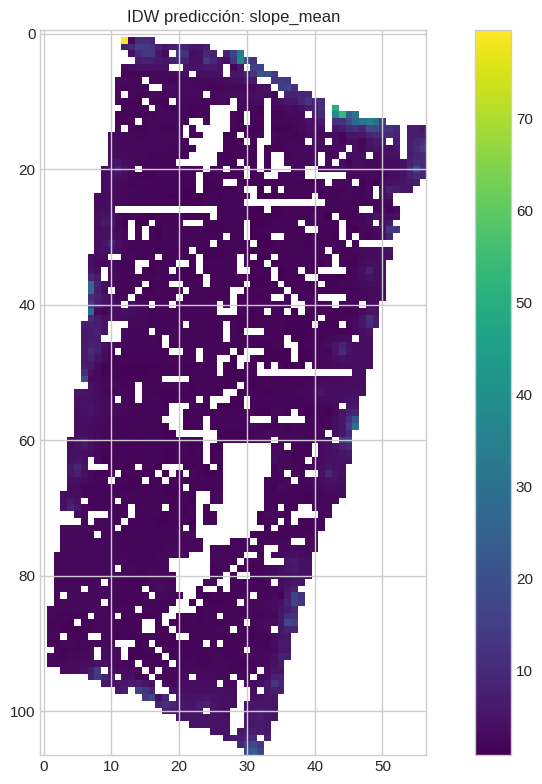


Validación cruzada
   fold   method       MAE      RMSE        R2    variable
0     1  Kriging  2.119789  5.217195  0.192661  slope_mean
1     1      IDW  2.149041  5.488502  0.106510  slope_mean
2     2  Kriging  1.799811  7.086176  0.089189  slope_mean
3     2      IDW  1.749144  7.255219  0.045215  slope_mean
4     3  Kriging  2.698245  7.040419  0.378407  slope_mean
5     3      IDW  2.788661  7.719157  0.252779  slope_mean
6     4  Kriging  2.081240  4.693560  0.560068  slope_mean
7     4      IDW  2.228467  5.364391  0.425326  slope_mean
8     5  Kriging  2.113094  5.403631 -0.055098  slope_mean
9     5      IDW  1.849941  4.999302  0.096891  slope_mean

Resumen por método:
              MAE      RMSE        R2
method                               
IDW      2.153051  6.165314  0.185344
Kriging  2.162436  5.888196  0.233045
✅ Pipeline completado.


In [20]:
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)

# --- CONFIG PARÁMETROS ---
VARIABLES_CONTINUAS = ['pop_density', 'ndvi_mean', 'slope_mean']  # Ajusta según tu análisis
TARGET_CRS = CRS.from_epsg(32719)  # UTM 19S (Santiago)
GRID_RESOLUTION = 50  # metros
N_FOLDS = 5
IDW_POWER = 2
MIN_POINTS = 20  # mínimo de puntos válidos para poder ajustar variograma/kriging

# --- UTILIDADES ESPACIALES ---
def ensure_projected(gdf, target_crs=TARGET_CRS):
    """Reproyecta a CRS métrico si es necesario."""
    if gdf.crs is None:
        raise ValueError("gdf_master no tiene CRS definido.")
    if gdf.crs != target_crs:
        return gdf.to_crs(target_crs)
    return gdf

def centroids_from_polygons(gdf):
    """Convierte polígonos a puntos (centroides)."""
    gdf_pts = gdf.copy()
    gdf_pts['geometry'] = gdf_pts.geometry.centroid
    return gdf_pts

def build_grid(gdf_pts, resolution=GRID_RESOLUTION):
    """Construye grid regular (extent del bounding box)."""
    bounds = gdf_pts.total_bounds  # minx, miny, maxx, maxy
    minx, miny, maxx, maxy = bounds
    # Aumentar un pequeño margen
    pad = resolution * 1
    minx -= pad; miny -= pad; maxx += pad; maxy += pad

    xs = np.arange(minx, maxx, resolution)
    ys = np.arange(miny, maxy, resolution)
    grid_x, grid_y = np.meshgrid(xs, ys)
    return grid_x, grid_y, xs, ys

def mask_grid_to_union_polygon(gdf, grid_x, grid_y):
    """Opcional: enmascara grid a la unión geométrica de las manzanas (para no predecir fuera)."""
    union_geom = gdf.unary_union
    points = [Point(x, y) for x, y in zip(grid_x.ravel(), grid_y.ravel())]
    mask = np.array([union_geom.contains(pt) for pt in points]).reshape(grid_x.shape)
    return mask

# --- VARIOGRAMAS ---
def compute_variogram(coords, values, estimator='matheron', max_dist=None, n_lags=12):
    """
    Ajusta semivariograma omnidireccional.
    coords: array Nx2
    values: array N
    """
    V = Variogram(coords, values, estimator=estimator, n_lags=n_lags, max_dist=max_dist, normalize=False)
    return V

def compute_directional_variograms(coords, values, angles=[0, 45, 90, 135], tolerance=22.5, n_lags=12, max_dist=None):
    """Ajusta variogramas direccionales para análisis de anisotropía."""
    dir_vars = {}
    for a in angles:
        DV = DirectionalVariogram(coords, values, direction=a, tolerance=tolerance,
                                  n_lags=n_lags, max_dist=max_dist)
        dir_vars[a] = DV
    return dir_vars

def plot_variogram(V, title, save_path):
    fig, ax = plt.subplots()
    bins = V.bins
    gamma = V.experimental
    ax.plot(bins, gamma, 'o-', label='Experimental')
    # Modelo ajustado
    h = np.linspace(0, bins.max(), 100)
    ax.plot(h, V.fitted_model(h), '-', label=f'Modelo: {V.model.__name__}')
    ax.set_xlabel('Distancia (m)')
    ax.set_ylabel('Semivariancia')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)


def plot_directional_variograms(dir_vars, title, save_path):
    """Grafica variogramas direccionales."""
    fig, ax = plt.subplots()
    for angle, DV in dir_vars.items():
        bins = DV.bins
        gamma = DV.experimental
        ax.plot(bins, gamma, 'o-', label=f'{angle}°')
    ax.set_xlabel('Distancia (m)')
    ax.set_ylabel('Semivariancia')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)

# --- KRIGING ---
def ordinary_kriging(coords, values, grid_x, grid_y, variogram_model='spherical'):
    """
    Ejecuta Ordinary Kriging de pykrige.
    variogram_model: 'linear', 'power', 'gaussian', 'spherical', 'exponential', 'hole-effect'
    Devuelve predicciones y varianzas.
    """
    ok = OrdinaryKriging(
        coords[:,0], coords[:,1], values,
        variogram_model=variogram_model,
        enable_plotting=False,
        coordinates_type='euclidean'
    )
    z, ss = ok.execute('grid', grid_x[0,:], grid_y[:,0])  # pykrige espera 1D arrays
    return np.array(z), np.array(ss)

# --- IDW ---
def idw_interpolation(coords, values, grid_x, grid_y, power=IDW_POWER, eps=1e-12):
    """
    Interpolación IDW sobre grid usando cKDTree.
    """
    tree = cKDTree(coords)
    # Vecinos: todos los puntos (puedes limitar k si deseas)
    gx = grid_x.ravel(); gy = grid_y.ravel()
    dists, idxs = tree.query(np.vstack([gx, gy]).T, k=coords.shape[0], workers=-1)
    weights = 1.0 / (dists**power + eps)
    wsum = np.sum(weights, axis=1)
    z = np.sum(weights * values[idxs], axis=1) / wsum
    return z.reshape(grid_x.shape)

# --- RÁSTER OUTPUT ---
def save_raster(array, xs, ys, crs, out_path, nodata=np.nan):
    """
    Guarda un array (matriz) como GeoTIFF. Origen en esquina superior izquierda.
    xs: coordenadas X del grid (1D)
    ys: coordenadas Y del grid (1D), asumimos index 0 es fila superior -> transform usa from_origin con y_max
    """
    pixel_size_x = xs[1] - xs[0]
    pixel_size_y = ys[1] - ys[0]
    transform = from_origin(xs.min(), ys.max(), pixel_size_x, pixel_size_y)
    height, width = array.shape
    profile = {
        'driver': 'GTiff',
        'height': height,
        'width': width,
        'count': 1,
        'dtype': 'float32',
        'crs': crs,
        'transform': transform,
        'nodata': nodata
    }
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(array.astype('float32'), 1)

# --- VALIDACIÓN CRUZADA ---
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def cross_validate_interpolators(coords, values, n_splits=5, variogram_model='spherical', idw_power=IDW_POWER):
    """
    CV punto-a-punto: para cada fold, predice los puntos de test usando:
      - Kriging entrenado en train y predicho en las coords de test (no en grid)
      - IDW con puntos train prediciendo en coords test
    Reporta MAE, RMSE, R2 comparados.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(coords)):
        Xtr, ytr = coords[tr_idx], values[tr_idx]
        Xte, yte = coords[te_idx], values[te_idx]

        # Kriging: ejecutar en modo 'points'
        ok = OrdinaryKriging(Xtr[:,0], Xtr[:,1], ytr, variogram_model=variogram_model,
                             enable_plotting=False, coordinates_type='euclidean')
        z_k, ss_k = ok.execute('points', Xte[:,0], Xte[:,1])
        z_k = np.array(z_k)

        # IDW: construir árbol solo con train
        tree = cKDTree(Xtr)
        dists, idxs = tree.query(Xte, k=Xtr.shape[0], workers=-1)
        weights = 1.0 / (dists**idw_power + 1e-12)
        wsum = np.sum(weights, axis=1)
        z_idw = np.sum(weights * ytr[idxs], axis=1) / wsum

        # Métricas
        mae_k = mean_absolute_error(yte, z_k)
        rmse_k = mean_squared_error(yte, z_k, squared=False)
        r2_k = r2_score(yte, z_k)

        mae_i = mean_absolute_error(yte, z_idw)
        rmse_i = mean_squared_error(yte, z_idw, squared=False)
        r2_i = r2_score(yte, z_idw)

        records.append({
            'fold': fold+1,
            'method': 'Kriging',
            'MAE': mae_k,
            'RMSE': rmse_k,
            'R2': r2_k
        })
        records.append({
            'fold': fold+1,
            'method': 'IDW',
            'MAE': mae_i,
            'RMSE': rmse_i,
            'R2': r2_i
        })

    return pd.DataFrame(records)

# --- PIPELINE PRINCIPAL ---
def run_pipeline(gdf_master, variables=VARIABLES_CONTINUAS, grid_resolution=GRID_RESOLUTION,
                 variogram_model='spherical'):
    # 1. CRS métrico y puntos
    gdf_proj = ensure_projected(gdf_master)
    gdf_pts = centroids_from_polygons(gdf_proj)

    # 2. Grid
    grid_x, grid_y, xs, ys = build_grid(gdf_pts, resolution=grid_resolution)
    # Opcional: máscara a unión
    mask = mask_grid_to_union_polygon(gdf_proj, grid_x, grid_y)

    # 3. Loop por variable
    all_cv = []  # para consolidado
    for var in variables:
        # Selección y limpieza
        dfv = gdf_pts[[var, 'geometry']].dropna().copy()
        # Algunas variables pueden tener valores no finitos
        dfv = dfv[np.isfinite(dfv[var])]

        if dfv.shape[0] < MIN_POINTS:
            print(f"⚠️ {var}: insuficiente ({dfv.shape[0]} puntos). Saltando.")
            continue

        coords = np.vstack([dfv.geometry.x.values, dfv.geometry.y.values]).T
        values = dfv[var].values.astype(float)

        # --- Semivariograma omnidireccional
        V = compute_variogram(coords, values, n_lags=12)
        # Guardar parámetros del variograma
        vario_params = {
            'variable': var,
            'model': V.model.__name__,
            'nugget': float(V.parameters[0]),
            'sill': float(V.parameters[1]),
            'range': float(V.parameters[2]),
            'bins_count': int(len(V.bins))
        }

        print("\nParámetros del variograma")
        for k, v in vario_params.items():
            print(f"  {k}: {v}")
        
        with open(os.path.join(MODELS_DIR, f'variogram_{var}.json'), 'w') as f:
            json.dump(vario_params, f, indent=2)

        # Graficar variograma
        plot_variogram(V, title=f"Semivariograma {var} (omnidir.)",
                       save_path=os.path.join(FIG_DIR, f'variogram_{var}.png'))

        # --- Anisotropía: variogramas direccionales
        dir_vars = compute_directional_variograms(coords, values)
        plot_directional_variograms(dir_vars, title=f"Semivariogramas direccionales {var}",
                                    save_path=os.path.join(FIG_DIR, f'directional_variograms_{var}.png'))

        # Guardar CSV
        vario_report = pd.DataFrame({
            'distance_bin_m': V.bins,
            'gamma': V.experimental
        })

        print("\nVariograma experimental (primeras filas)")
        print(vario_report.head())
        print("\nResumen estadístico:")
        print(vario_report.describe())
        
        vario_report.to_csv(os.path.join(REPORTS_DIR, f'variogram_experimental_{var}.csv'), index=False)

        # --- Interpolación: Kriging
        z_krig, ss_krig = ordinary_kriging(coords, values, grid_x, grid_y, variogram_model=V.model.__name__)
        # Aplicar máscara
        z_krig_masked = np.where(mask, z_krig, np.nan)
        ss_krig_masked = np.where(mask, ss_krig, np.nan)

        print(f"\nKriging {var}")
        print("Predicción:")
        print(f"  min={np.nanmin(z_krig_masked):.3f}, "
              f"max={np.nanmax(z_krig_masked):.3f}, "
              f"mean={np.nanmean(z_krig_masked):.3f}")
        
        print("Varianza:")
        print(f"  min={np.nanmin(ss_krig_masked):.3f}, "
              f"max={np.nanmax(ss_krig_masked):.3f}, "
              f"mean={np.nanmean(ss_krig_masked):.3f}")

        # Guardar ráster de predicción y varianza
        save_raster(z_krig_masked, xs, ys, gdf_proj.crs, os.path.join(MODELS_DIR, f'kriging_{var}.tif'))
        save_raster(ss_krig_masked, xs, ys, gdf_proj.crs, os.path.join(MODELS_DIR, f'kriging_variance_{var}.tif'))

        # Graficar predicción y varianza
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))
        im0 = ax[0].imshow(z_krig_masked, origin='upper', cmap='viridis')
        ax[0].set_title(f'Kriging predicción: {var}')
        plt.colorbar(im0, ax=ax[0])
        im1 = ax[1].imshow(ss_krig_masked, origin='upper', cmap='magma')
        ax[1].set_title(f'Kriging varianza (incertidumbre): {var}')
        plt.colorbar(im1, ax=ax[1])
        plt.tight_layout()
        plt.show()
        fig.savefig(os.path.join(FIG_DIR, f'kriging_{var}.png'), dpi=200)
        plt.close(fig)

        # --- Interpolación: IDW
        z_idw = idw_interpolation(coords, values, grid_x, grid_y, power=IDW_POWER)
        z_idw_masked = np.where(mask, z_idw, np.nan)

        save_raster(z_idw_masked, xs, ys, gdf_proj.crs, os.path.join(MODELS_DIR, f'idw_{var}.tif'))

        print(f"\nIDW {var}")
        print(f"  min={np.nanmin(z_idw_masked):.3f}, "
              f"max={np.nanmax(z_idw_masked):.3f}, "
              f"mean={np.nanmean(z_idw_masked):.3f}")
        
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(z_idw_masked, origin='upper', cmap='viridis')
        ax.set_title(f'IDW predicción: {var}')
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
        fig.savefig(os.path.join(FIG_DIR, f'idw_{var}.png'), dpi=200)
        plt.close(fig)

        # --- Validación cruzada (Kriging vs IDW)
        cv_df = cross_validate_interpolators(coords, values, n_splits=N_FOLDS,
                                             variogram_model=V.model.__name__, idw_power=IDW_POWER)
        cv_df['variable'] = var


        print("\nValidación cruzada")
        print(cv_df)
        
        print("\nResumen por método:")
        print(cv_df.groupby('method')[['MAE', 'RMSE', 'R2']].mean())
        
        cv_df.to_csv(os.path.join(REPORTS_DIR, f'cv_{var}.csv'), index=False)
        all_cv.append(cv_df)

        # --- Reporte resumen por variable
        summary = {
            'variable': var,
            'kriging_model': V.model.__name__,
            'n_points': int(len(values)),
            'grid_resolution_m': GRID_RESOLUTION
        }
        with open(os.path.join(REPORTS_DIR, f'summary_{var}.json'), 'w') as f:
            json.dump(summary, f, indent=2)

    # Consolidado CV
    if all_cv:
        cv_all = pd.concat(all_cv, axis=0, ignore_index=True)
        cv_all.to_csv(os.path.join(REPORTS_DIR, 'cv_all_variables.csv'), index=False)
    print("✅ Pipeline completado.")

# --- EJECUCIÓN ---
run_pipeline(gdf_master, variables=VARIABLES_CONTINUAS, grid_resolution=GRID_RESOLUTION)
